Import Library

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
warnings.filterwarnings("ignore")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

Download Dataset

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "samithsachidanandan/human-face-emotions"
)

data_dir = os.path.join(dataset_path, "Data")

print("Dataset Path :", data_dir)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Dataset Path : /kaggle/input/human-face-emotions/Data


Cek Kelas dan Distribusi Data

,Emotion,Count
0,Angry,10148
1,Fear,9732
2,Happy,18439
3,Sad,12553
4,Suprise,8227


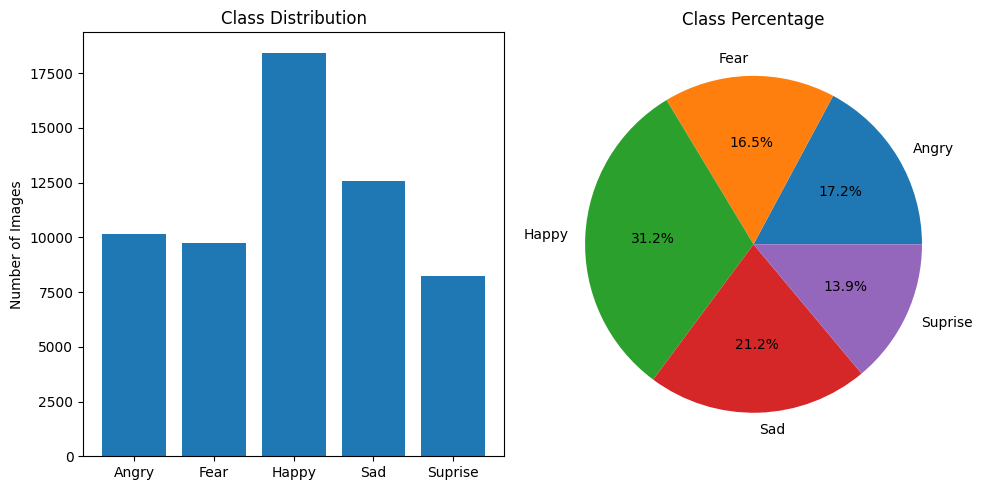

In [3]:
class_names = sorted(os.listdir(data_dir))

class_counts = []

for cls in class_names:

    cls_path = os.path.join(data_dir, cls)

    count = len(os.listdir(cls_path))

    class_counts.append([cls, count])

df_counts = pd.DataFrame(
    class_counts,
    columns=["Emotion", "Count"]
)

display(df_counts)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.bar(
    df_counts["Emotion"],
    df_counts["Count"]
)

plt.title("Class Distribution")
plt.ylabel("Number of Images")

plt.subplot(1,2,2)

plt.pie(
    df_counts["Count"],
    labels=df_counts["Emotion"],
    autopct="%1.1f%%"
)

plt.title("Class Percentage")

plt.tight_layout()
plt.show()

Analisis Ukuran Gambar

In [4]:
image_sizes = []

for cls in class_names:

    folder = os.path.join(data_dir, cls)

    sample_files = os.listdir(folder)[:1000]

    for file in sample_files:

        path = os.path.join(folder, file)

        try:

            img = Image.open(path)

            width, height = img.size

            image_sizes.append([width, height])

        except:
            pass

df_size = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

display(df_size.describe())

,Width,Height
count,5000.000000,5000.000000
mean,86.438800,80.832400
std,407.238204,331.209922
min,48.000000,48.000000
25%,48.000000,48.000000
50%,48.000000,48.000000
75%,48.000000,48.000000
max,8192.000000,6018.000000


Visualisasi Sampel Tiap Kelas

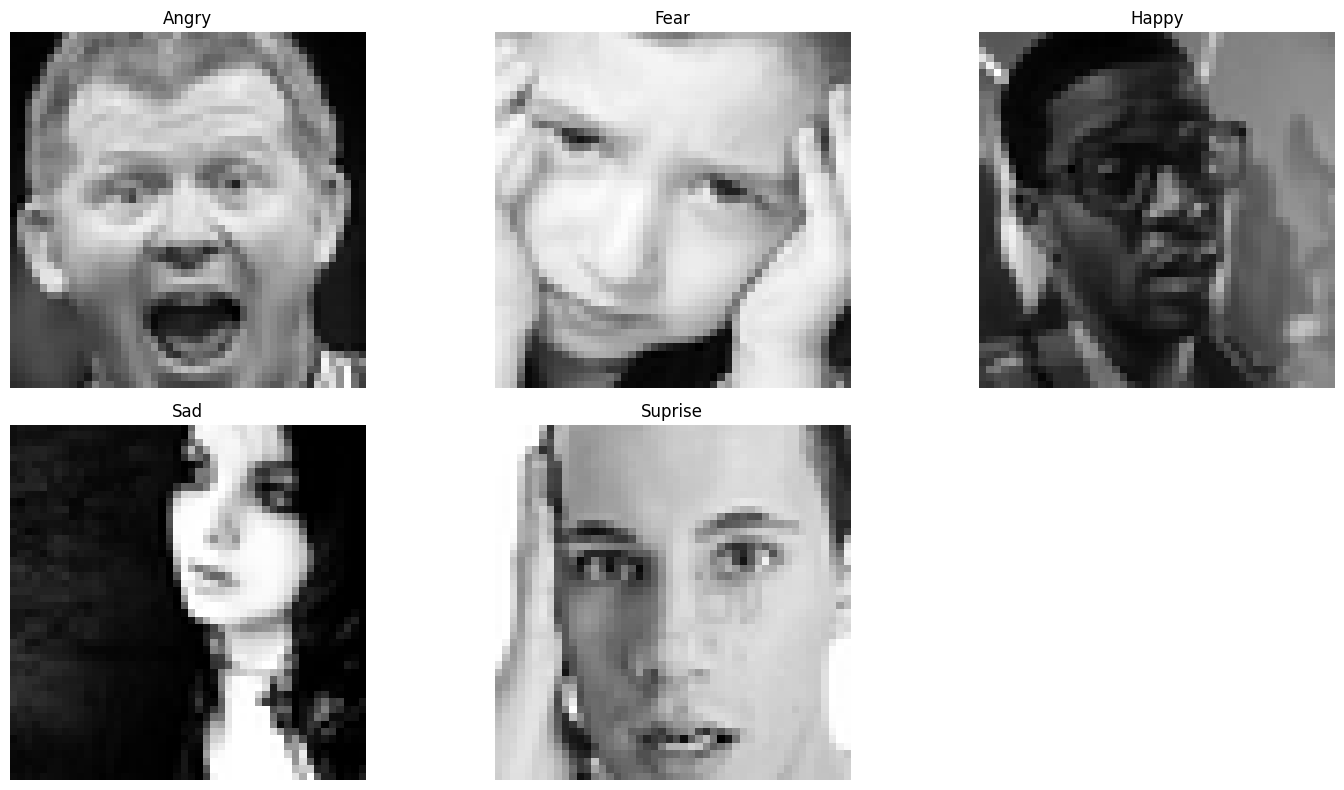

In [5]:
plt.figure(figsize=(15,8))

for i, cls in enumerate(class_names):

    folder = os.path.join(data_dir, cls)

    sample_img = random.choice(
        os.listdir(folder)
    )

    img_path = os.path.join(
        folder,
        sample_img
    )

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

PARAMETER

In [6]:
IMG_SIZE = (48, 48)

BATCH_SIZE = 64

EPOCHS = 100

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int")

CLASS_NAMES = train_ds.class_names

print(CLASS_NAMES)

Found 59099 files belonging to 5 classes.
Using 41370 files for training.
['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']


In [8]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int")

Found 59099 files belonging to 5 classes.
Using 17729 files for validation.


In [9]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_ds = temp_ds.take(temp_batches // 2)

test_ds = temp_ds.skip(temp_batches // 2)

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.1),

    RandomZoom(0.1),

    RandomContrast(0.1)])

In [12]:
train_ds = train_ds.shuffle(5000).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

In [13]:
model = Sequential([

    Input(shape=(48,48,1)),

    data_augmentation,

    # BLOCK 1
    Conv2D(64,3,padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(64,3,padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.25),

    # BLOCK 2
    Conv2D(128,3,padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(128,3,padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.25),

    # BLOCK 3
    Conv2D(256,3,padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(256,3,padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.30),

    # BLOCK 4
    Conv2D(512,3,padding="same",activation="relu"),
    BatchNormalization(),

    Conv2D(512,3,padding="same",activation="relu"),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.35),

    # HEAD
    GlobalAveragePooling2D(),

    Dense(512,activation="relu"),
    BatchNormalization(),
    Dropout(0.50),

    Dense(256,activation="relu"),
    BatchNormalization(),
    Dropout(0.40),

    Dense(
        len(CLASS_NAMES),
        activation="softmax"
    )

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,090,245 (19.42 MB)

 Trainable params: 5,084,869 (19.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [14]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1
)

In [16]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/100
647/647 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2452 - loss: 2.1129
Epoch 1: val_accuracy improved from None to 0.31790, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
647/647 ━━━━━━━━━━━━━━━━━━━━ 168s 102ms/step - accuracy: 0.2556 - loss: 1.9608 - val_accuracy: 0.3179 - val_loss: 1.5807 - learning_rate: 3.0000e-04
Epoch 2/100
647/647 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3214 - loss: 1.6551
Epoch 2: val_accuracy improved from 0.31790 to 0.47684, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
647/647 ━━━━━━━━━━━━━━━━━━━━ 98s 89ms/step - accuracy: 0.3574 - loss: 1.5720 - val_accuracy: 0.4768 - val_loss: 1.4202 - learning_rate: 3.0000e-04
Epoch 3/100
647/647 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4557 - loss: 1.3384
Epoch 3: val_accuracy improved from 0.47684 to 0.55800, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
647/647 ━━━━━━━━━━━━

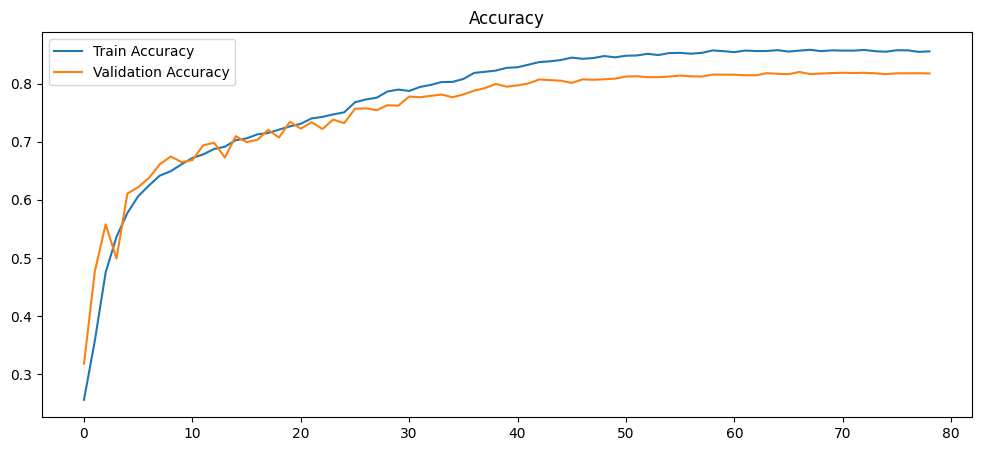

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy")

plt.legend()

plt.show()

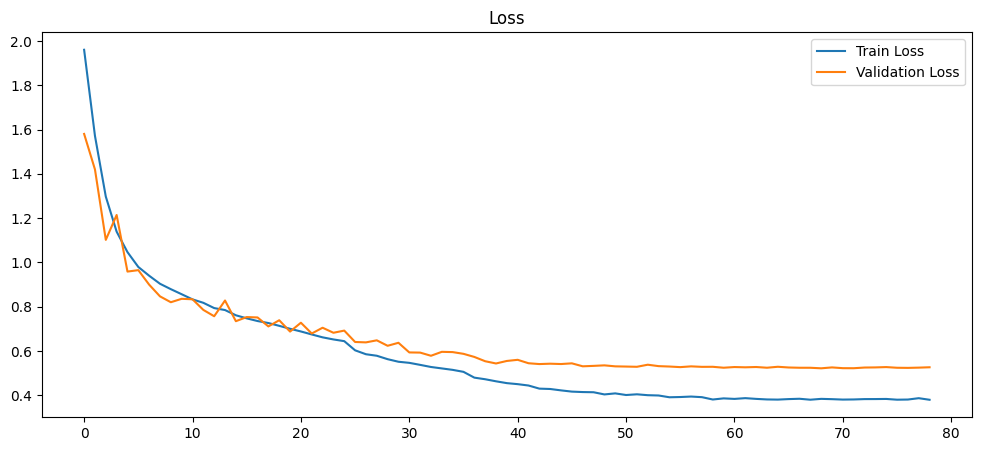

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss")

plt.legend()

plt.show()

In [19]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(
    f"Test Accuracy : {test_acc:.4f}"
)

print(
    f"Test Loss : {test_loss:.4f}"
)

139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 131ms/step - accuracy: 0.8161 - loss: 0.5243
Test Accuracy : 0.8161
Test Loss : 0.5243


In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(
        images,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_true.extend(labels.numpy())

    y_pred.extend(preds)

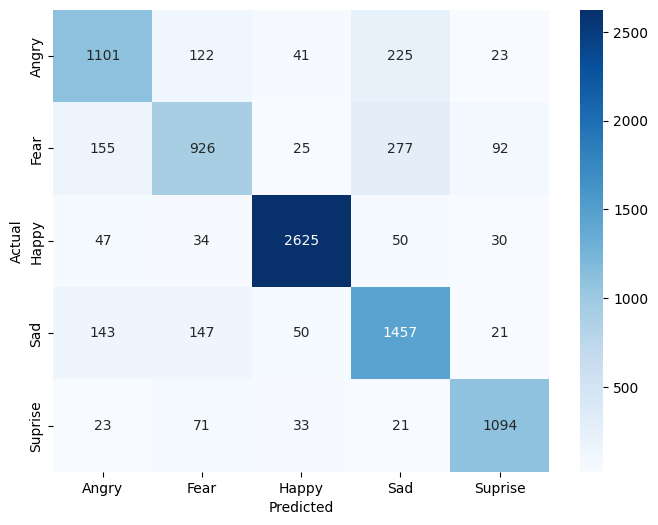

In [21]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

       Angry       0.75      0.73      0.74      1512
        Fear       0.71      0.63      0.67      1475
       Happy       0.95      0.94      0.94      2786
         Sad       0.72      0.80      0.76      1818
     Suprise       0.87      0.88      0.87      1242

    accuracy                           0.82      8833
   macro avg       0.80      0.80      0.80      8833
weighted avg       0.82      0.82      0.81      8833

